## Import TensorFlow and other libraries

In [1]:
import tensorflow as tf
import tensorflow_io as tfio

import os
from pathlib import Path
import time
import datetime
import numpy as np
import cv2

from matplotlib import pyplot as plt
from IPython.display import display, clear_output, update_display
from tqdm.notebook import tqdm

from joblib import Memory
from joblib import Parallel, delayed

/home/rafa/miniconda3/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/home/rafa/miniconda3/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/home/rafa/miniconda3/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl5mutexC1Ev']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/home/rafa/miniconda3/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/home/rafa/miniconda3/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/home/rafa/miniconda3/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZNK10tensorflow4data11DatasetBas

In [2]:
TESTING_LOSS = "pix2pix"
# The batch size of 1 produced better results for the U-Net in the original pix2pix experiment
BATCH_SIZE = 1
# Each image is 64x64 in size
IMG_WIDTH = 64
IMG_HEIGHT = 64

FRAMES_GROUP_SIZE =  2
N_CHANNELS = 3

## Create cache dir

In [3]:
cachedir = Path('output/cache')
cachedir.mkdir(exist_ok=True)
memory = Memory(cachedir, verbose=0)

## Load the dataset

In [4]:
PATH = Path('../data/mnist_test_seq_rgb.npy')
# load normalizer rgb data
# PATH = Path('../data/mnist_test_seq_rgb_normalized.npy')
sequences = np.load(PATH)

In [5]:
# Normalizing the images to [-1, 1]
def normalize(sequence):
  return (sequence / 127.5) - 1

# Undo normalizing the images to [0, 255]
@tf.function
def normalized_sequence_to_images(sequence):
  return tf.cast((sequence + 1) * 127.5, tf.uint8)

In [6]:
# Normalize sequerences to [-1, 1]
sequences = normalize(sequences)

Each original image is of size `64 x 64`:

In [7]:
print(sequences.shape)
sample_sequence = sequences[0,...]
print(sample_sequence.shape)

(10000, 20, 64, 64, 3)
(20, 64, 64, 3)


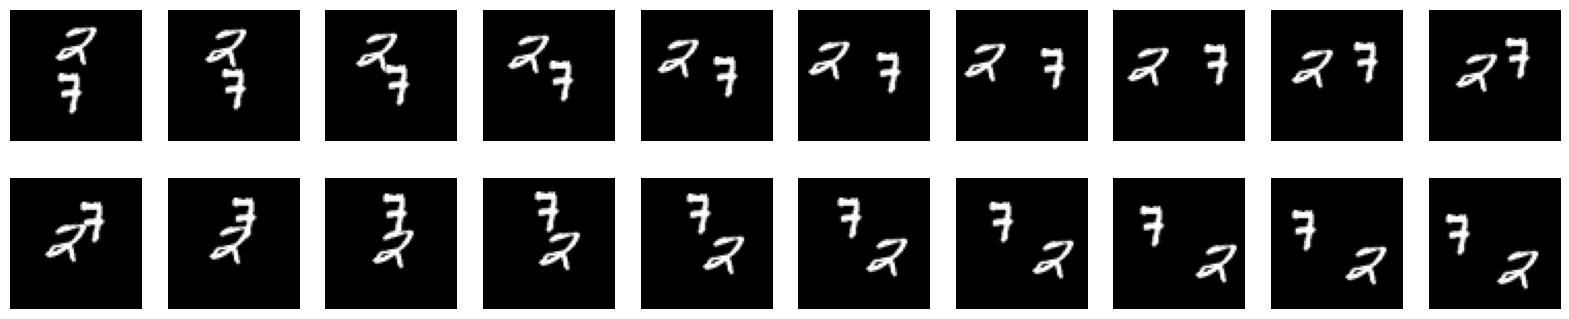

In [8]:
def plot_sample_sequence(sample_sequence):
    plot_sequence = list(sample_sequence)
    n_frames = len(plot_sequence)
    rows = ((n_frames-1) // 10)+1
    cols = max(n_frames % 10, 10)
    fig = plt.figure(figsize=(20, 4))
    for i, im in enumerate(plot_sequence):
        ax = fig.add_subplot(rows,cols,i+1)
        ax.imshow(im, cmap='gray') 
        ax.axis('off')
    plt.show()
    plt.close()

def sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[0]):
        yield sample_sequence[i, ...]

def plot_sequence(sample_sequence):
    plot_sample_sequence(sequence_generator(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def inverse_sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[-1]):
        yield sample_sequence[..., i]

def plot_inverse_sequence(sample_sequence):
    plot_sample_sequence(inverse_sequence_generator(sample_sequence))

def plot_normalized_inverse_sequence(sample_sequence):
    plot_inverse_sequence(normalized_sequence_to_images(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def plot_sequence_from_tensor(sample_sequence):
    if len(sample_sequence.shape) == 5 and sample_sequence.shape[0] == 1:
        plot_sequence(sample_sequence[0])
    else:
        raise ValueError("The tensor must be of shape (1, frames, height, width, channels)")

def plot_sequence_from_normalized_tensor(sample_sequence):
    plot_sequence_from_tensor(normalized_sequence_to_images(sample_sequence))

plot_normalized_sequence(sample_sequence)

## Build an input pipeline with `tf.keras.utils.Sequence`

In [9]:
DATASET_SIZE = sequences.shape[0]
train_size = int(0.7 * DATASET_SIZE)
# val_size = int(0.15 * DATASET_SIZE)
test_size = int(0.3 * DATASET_SIZE)

# generate training, validation and test sets
train_sequences = sequences[:train_size]
# val_sequences = sequences[train_size:train_size+val_size]
# test_sequences = sequences[train_size+val_size:]
test_sequences = sequences[train_size:]

print(train_sequences.shape)
# print(val_sequences.shape)
print(test_sequences.shape)

(7000, 20, 64, 64, 3)
(3000, 20, 64, 64, 3)


In [10]:
# create input sequence by repeating the first frame
def generate_input_from_target(target):
  return tf.concat([target[:, 0:1, ...]] * FRAMES_GROUP_SIZE, axis=1)

In [11]:
class SequencesDataGenerator(tf.keras.utils.Sequence):
    
    def __init__(self, sequences, batch_size, frames_group_size):
        n, clip_size, height, width, channels = sequences.shape
        self._sequences = sequences.reshape(n, (clip_size//frames_group_size), frames_group_size, height, width, channels)
        self.batch_size = batch_size
        self.n = n
        self.frames_group_size = frames_group_size
        self.clip_size = clip_size
        self.groups_per_clip = clip_size // frames_group_size
    
    def get_clip_index(self, i):
        return i // self.groups_per_clip
    
    def get_frame_index(self, i):
        return i % self.groups_per_clip
    
    def get_video_number(self, i):
        return i * self.frames_group_size // self.clip_size
    
    def _get_clip_batch(self, i):
        clip_index = self.get_clip_index(i)
        frame_index = self.get_frame_index(i)
        begin_batch = clip_index * self.batch_size
        end_batch = begin_batch + self.batch_size
        batch_sequences = self._sequences[begin_batch:end_batch, frame_index, ...]
        return batch_sequences
    
    def is_first_frame_of_a_video(self, i):
        return self.get_video_number(i) != self.get_video_number(i-1)
    
    def __getitem__(self, i):
        target_sequence = self._get_clip_batch(i)
        if self.is_first_frame_of_a_video(i):
            input_sequence = generate_input_from_target(target_sequence)
        else:
            input_sequence = self._get_clip_batch(i-1)
        return input_sequence, self._get_clip_batch(i)

    def predict(self, i, model, training=False):
        input_sequence, target_sequence = self[i]
        predicted_output = model(input_sequence, training=training)
        return input_sequence, target_sequence, predicted_output
        
    def __len__(self):
        return self.n // self.batch_size
    
    def __call__(self):
        for i in range(len(self)):
            yield self[i]

In [12]:
train_generator = SequencesDataGenerator(train_sequences, BATCH_SIZE, FRAMES_GROUP_SIZE)
test_generator = SequencesDataGenerator(test_sequences, BATCH_SIZE, FRAMES_GROUP_SIZE)

print(test_generator[0][0].shape)
print(test_generator[1][0].shape)

(1, 2, 64, 64, 3)
(1, 2, 64, 64, 3)


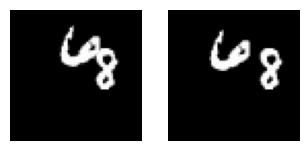

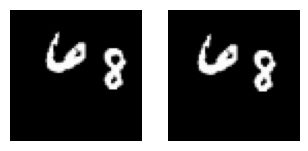

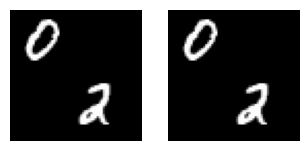

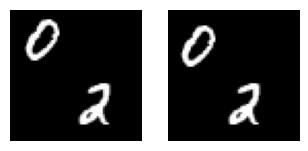

In [13]:
for i in range(9,11):
    sample_input, sample_target = test_generator[i]
    plot_sequence_from_normalized_tensor(sample_input)
    plot_sequence_from_normalized_tensor(sample_target)

## Build the generator

The generator of your pix2pix cGAN is a _modified_ [U-Net](https://arxiv.org/abs/1505.04597){:.external}. A U-Net consists of an encoder (downsampler) and decoder (upsampler). (You can find out more about it in the [Image segmentation](../images/segmentation.ipynb) tutorial and on the [U-Net project website](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/){:.external}.)

- Each block in the encoder is: Convolution -> Batch normalization -> Leaky ReLU
- Each block in the decoder is: Transposed convolution -> Batch normalization -> Dropout (applied to the first 3 blocks) -> ReLU
- There are skip connections between the encoder and decoder (as in the U-Net).

Define the downsampler (encoder):

In [14]:
def downsample(filters, size, strides=2, apply_batchnorm=True):
  initializer = tf.random_normal_initializer(0., 0.02)

  result = tf.keras.Sequential()
  result.add(
      tf.keras.layers.Conv3D(filters, size, strides=strides, padding='same',
                             kernel_initializer=initializer, use_bias=False))

  if apply_batchnorm:
    result.add(tf.keras.layers.BatchNormalization())

  result.add(tf.keras.layers.LeakyReLU())

  return result

In [15]:
down_model = downsample(3, 4, (1,2,2))
sample = test_generator[0][0]
down_result = down_model(sample, 0)
print (down_result.shape)

(1, 2, 32, 32, 3)


Define the upsampler (decoder):

In [16]:
def upsample(filters, size, strides=2, apply_dropout=False):
  initializer = tf.random_normal_initializer(0., 0.02)

  result = tf.keras.Sequential()
  result.add(
    tf.keras.layers.Conv3DTranspose(filters, size, strides=strides,
                                    padding='same',
                                    kernel_initializer=initializer,
                                    use_bias=False))

  result.add(tf.keras.layers.BatchNormalization())

  if apply_dropout:
      result.add(tf.keras.layers.Dropout(0.5))

  result.add(tf.keras.layers.ReLU())

  return result

In [17]:
up_model = upsample(3, 4, (1,2,2))
up_result = up_model(down_result)
print (up_result.shape)
print(sample.shape)

(1, 2, 64, 64, 3)
(1, 2, 64, 64, 3)


Define the generator with the downsampler and the upsampler:

In [18]:
def Generator():
  inputs = tf.keras.layers.Input(shape=[FRAMES_GROUP_SIZE, IMG_WIDTH, IMG_HEIGHT, N_CHANNELS])

  down_stack = [
    downsample(128, 4, (1,2,2), apply_batchnorm=False),  # (batch_size, frames_group_size, 32, 32, 128)
    downsample(128, 4, (1,2,2)),  # (batch_size, frames_group_size, 16, 16, 128)
    downsample(256, 4, (1,2,2)),  # (batch_size, frames_group_size, 8, 8, 256)
    downsample(512, 4, (1,2,2)),  # (batch_size, frames_group_size, 4, 4, 512)
    downsample(512, 4, (1,2,2)),  # (batch_size, frames_group_size, 2, 2, 512)
  ]

  up_stack = [
    upsample(512, 4, (1,2,2), apply_dropout=True),  # (batch_size, frames_group_size, 4, 4, 512)
    upsample(256, 4, (1,2,2)),  # (batch_size, frames_group_size, 8, 8, 256)
    upsample(128, 4, (1,2,2)),  # (batch_size, frames_group_size, 16, 16, 256)
    upsample(128, 4, (1,2,2)),  # (batch_size, frames_group_size, 32, 32, 128)
  ]

  initializer = tf.random_normal_initializer(0., 0.02)
  last = tf.keras.layers.Conv3DTranspose(N_CHANNELS, 4,
                                         strides=(1,2,2),
                                         padding='same',
                                         kernel_initializer=initializer,
                                         activation='tanh')  # (batch_size, , frames_group_size, 64, 64, 3)

  x = inputs

  # Downsampling through the model
  skips = []
  for down in down_stack:
    x = down(x)
    skips.append(x)

  skips = reversed(skips[:-1])

  # Upsampling and establishing the skip connections
  for up, skip in zip(up_stack, skips):
    x = up(x)
    x = tf.keras.layers.Concatenate()([x, skip])

  x = last(x)

  return tf.keras.Model(inputs=inputs, outputs=x)

Visualize the generator model architecture:

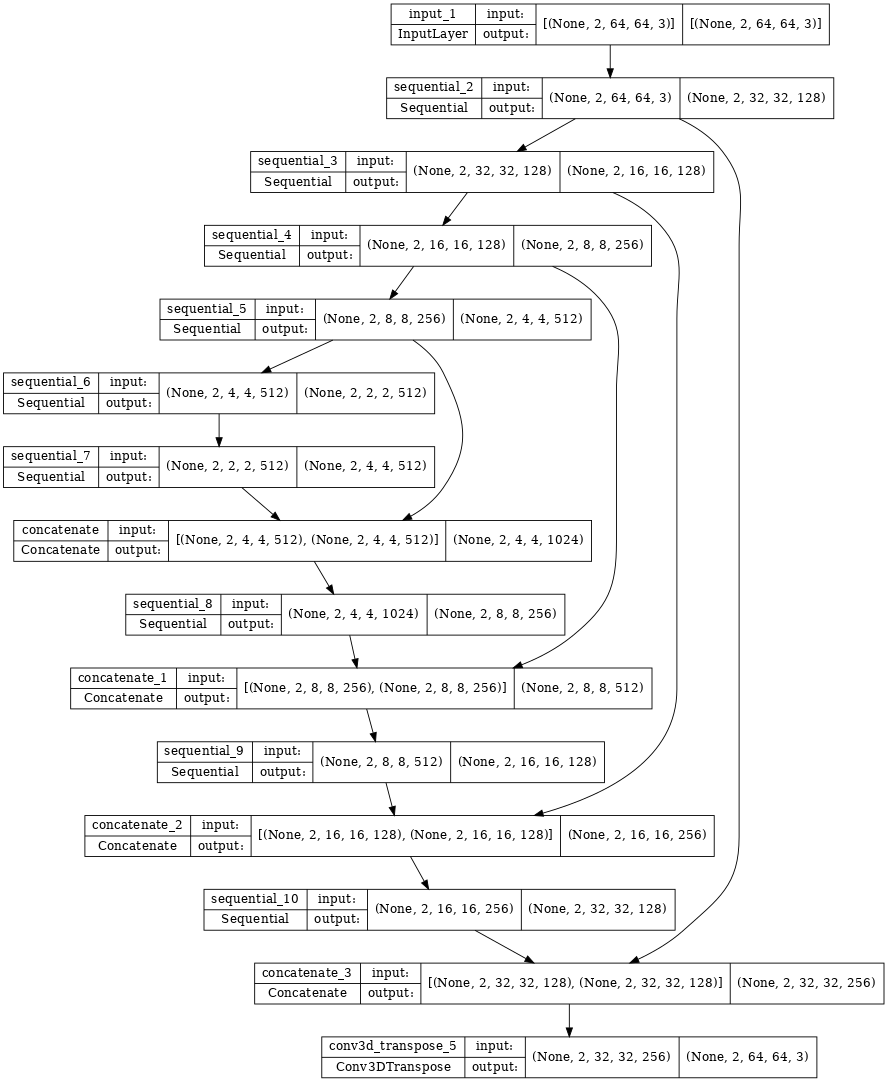

In [19]:
generator = Generator()
tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64, to_file='output/generator.png')

Test the generator:

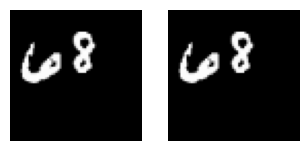

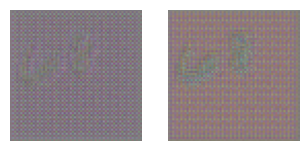

In [20]:
gen_output = generator(sample, training=False)
plot_sequence_from_normalized_tensor(sample)
plot_sequence_from_normalized_tensor(gen_output)

### Define the generator loss

GANs learn a loss that adapts to the data, while cGANs learn a structured loss that penalizes a possible structure that differs from the network output and the target image, as described in the [pix2pix paper](https://arxiv.org/abs/1611.07004){:.external}.

- The generator loss is a sigmoid cross-entropy loss of the generated images and an **array of ones**.
- The pix2pix paper also mentions the L1 loss, which is a MAE (mean absolute error) between the generated image and the target image.
- This allows the generated image to become structurally similar to the target image.
- The formula to calculate the total generator loss is `gan_loss + LAMBDA * l1_loss`, where `LAMBDA = 100`. This value was decided by the authors of the paper.

In [21]:
LAMBDA1 = 100
LAMBDA2 = 5

In [22]:
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [23]:
@tf.function
def pixel_difference_loss(previous, current):
  return  tf.math.abs(current-previous)

@tf.function
def apply_luminance_loss(image, loss_function):
  output = normalized_sequence_to_images(image)
  output = tfio.experimental.color.rgb_to_ycbcr(output)
  output = output[...,0] # get y from ycbcr
  output = tf.cast(output, tf.float32) # convert to float
  output = loss_function(output[:,:-1,...], output[:,1:,...])
  return output

@tf.function
def custom_loss_mean(y_true, y_pred, loss_function):
  loss_true = apply_luminance_loss(y_true, loss_function)
  loss_pred = apply_luminance_loss(y_pred, loss_function)
  return tf.math.reduce_mean(tf.abs(loss_true - loss_pred))

## Comparing loss functions

In [24]:
GENERATOR_LOSS_FUNCTIONS = {
    # 'mean_ratio_std': ratio_std,
    # 'mean_ratio_mean': ratio_mean,
    # 'mean_difference': absolute_difference,
    'mean_pixel_difference': pixel_difference_loss,
    # 'mean_pixel_ratio': ratio_sequences,
    # 'mean_pixel_ratio2': ratio_pixels,
    'pix2pix': None
}

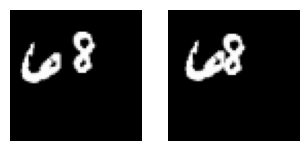

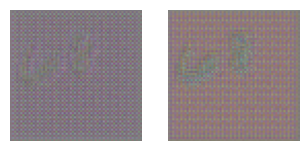

l1_loss
tf.Tensor(0.9792599, shape=(), dtype=float32)
LAMBDA1
100
LAMBDA2
5


In [25]:
gen_output_sample = generator(sample, training=False)
# plot_sequence_from_normalized_tensor(sample[0:1])
plot_sequence_from_normalized_tensor(test_generator[1][0][0:1])
plot_sequence_from_normalized_tensor(gen_output_sample[0:1])

# Mean absolute error
l1_loss = tf.reduce_mean(tf.abs(sample - gen_output_sample))

current_function_loss = GENERATOR_LOSS_FUNCTIONS[TESTING_LOSS]
if current_function_loss:
    # ratio_loss_value = custom_loss_mean(sample,gen_output_sample,current_function_loss)
    custom_loss_value = custom_loss_mean(test_generator[1][0],gen_output_sample,current_function_loss)
    print("custom_loss_value")
    print(custom_loss_value)

print("l1_loss")
print(l1_loss)
print("LAMBDA1")
print(LAMBDA1)
print("LAMBDA2")
print(LAMBDA2)

In [26]:
def generator_loss(disc_generated_output, gen_output, target):
  gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)

  loss_function = GENERATOR_LOSS_FUNCTIONS[TESTING_LOSS]
  if loss_function:
    custom = custom_loss_mean(target,gen_output,loss_function) * LAMBDA2
  else:
    custom = 0

  # Mean absolute error
  l1_loss = tf.reduce_mean(tf.abs(target - gen_output)) * LAMBDA1

  total_gen_loss = gan_loss + l1_loss + custom

  return total_gen_loss, gan_loss, l1_loss, custom

Comparing new loss function

The training procedure for the generator is as follows:

![Generator Update Image](https://github.com/tensorflow/docs/blob/master/site/en/tutorials/generative/images/gen.png?raw=1)


## Build the discriminator

The discriminator in the pix2pix cGAN is a convolutional PatchGAN classifier—it tries to classify if each image _patch_ is real or not real, as described in the [pix2pix paper](https://arxiv.org/abs/1611.07004){:.external}.

- Each block in the discriminator is: Convolution -> Batch normalization -> Leaky ReLU.
- The shape of the output after the last layer is `(batch_size, 30, 30, 1)`.
- Each `30 x 30` image patch of the output classifies a `70 x 70` portion of the input image.
- The discriminator receives 2 inputs: 
    - The input image and the target image, which it should classify as real.
    - The input image and the generated image (the output of the generator), which it should classify as fake.
    - Use `tf.concat([inp, tar], axis=-1)` to concatenate these 2 inputs together.

Let's define the discriminator:

In [27]:
def Discriminator():
  initializer = tf.random_normal_initializer(0., 0.02)

  inp = tf.keras.layers.Input(shape=[FRAMES_GROUP_SIZE, IMG_WIDTH, IMG_HEIGHT, N_CHANNELS], name='input_frame')
  tar = tf.keras.layers.Input(shape=[FRAMES_GROUP_SIZE, IMG_WIDTH, IMG_HEIGHT, N_CHANNELS], name='folowing_frame')

  x = tf.keras.layers.concatenate([inp, tar])  # (batch_size, 256, 256, channels*2)

  down1 = downsample(64, 4, (1,2,2), apply_batchnorm=False)(x)  # (batch_size, 128, 128, 64)
  down2 = downsample(128, 4, (1,2,2))(down1)  # (batch_size, 64, 64, 128)
  # down3 = downsample(256, 4)(down2)  # (batch_size, 32, 32, 256)

  zero_pad1 = tf.keras.layers.ZeroPadding3D()(down2)  # (batch_size, 34, 34, 256)
  conv = tf.keras.layers.Conv3D(256, 4, strides=1,
                                kernel_initializer=initializer,
                                use_bias=False)(zero_pad1)  # (batch_size, 31, 31, 512)

  batchnorm1 = tf.keras.layers.BatchNormalization()(conv)

  leaky_relu = tf.keras.layers.LeakyReLU()(batchnorm1)

  zero_pad2 = tf.keras.layers.ZeroPadding3D()(leaky_relu)  # (batch_size, 33, 33, 512)

  last = tf.keras.layers.Conv3D(1, 2, strides=1,
                                kernel_initializer=initializer)(zero_pad2)  # (batch_size, 30, 30, 1)

  return tf.keras.Model(inputs=[inp, tar], outputs=last)

Visualize the discriminator model architecture:

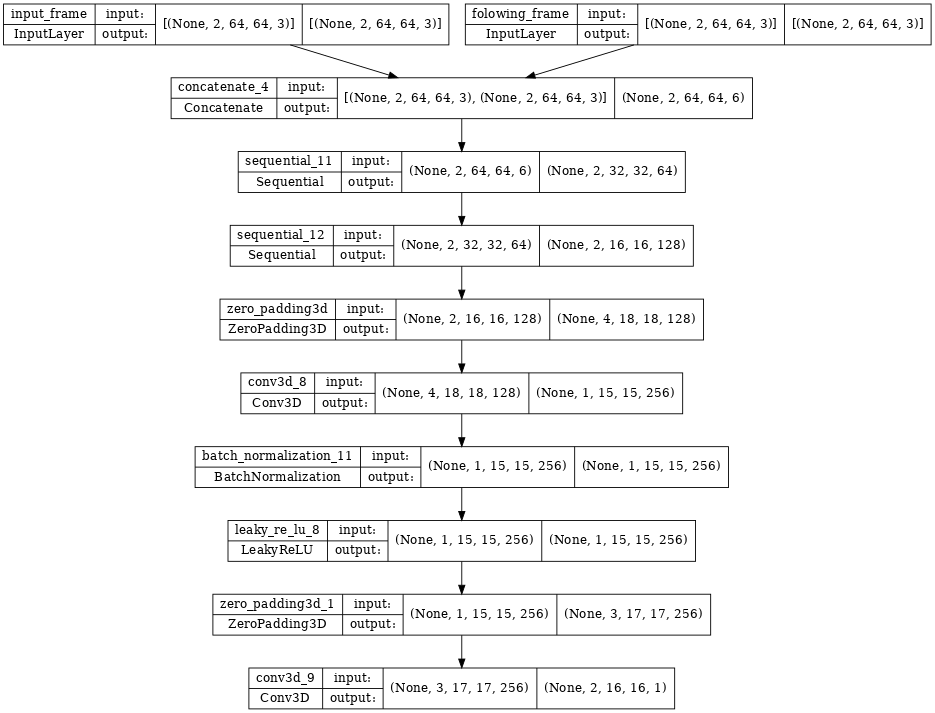

In [28]:
discriminator = Discriminator()
tf.keras.utils.plot_model(discriminator, show_shapes=True, dpi=64, to_file='output/discriminator.png')

Test the discriminator:

(1, 2, 16, 16, 1)


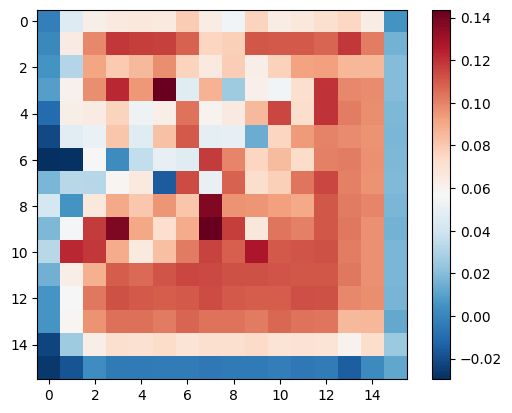

In [29]:
disc_out = discriminator([sample, gen_output_sample], training=False)
print(disc_out.shape)
plt.imshow(disc_out[0,0, ..., -1], cmap='RdBu_r')
plt.colorbar()
plt.show()
plt.close()

### Define the discriminator loss

- The `discriminator_loss` function takes 2 inputs: **real images** and **generated images**.
- `real_loss` is a sigmoid cross-entropy loss of the **real images** and an **array of ones(since these are the real images)**.
- `generated_loss` is a sigmoid cross-entropy loss of the **generated images** and an **array of zeros (since these are the fake images)**.
- The `total_loss` is the sum of `real_loss` and `generated_loss`.

In [30]:
def discriminator_loss(disc_real_output, disc_generated_output):
  real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)

  generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)

  total_disc_loss = real_loss + generated_loss

  return total_disc_loss

The training procedure for the discriminator is shown below.

To learn more about the architecture and the hyperparameters you can refer to the [pix2pix paper](https://arxiv.org/abs/1611.07004){:.external}.

![Discriminator Update Image](https://github.com/tensorflow/docs/blob/master/site/en/tutorials/generative/images/dis.png?raw=1)


## Define the optimizers and a checkpoint-saver


In [31]:
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [32]:
BASE_DIR = f'output/pix2pix_{TESTING_LOSS}_l1_{LAMBDA1}_l2_{LAMBDA2}'
checkpoint_dir = str(Path(BASE_DIR) / 'training_checkpoints')
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

## Generate images

Write a function to plot some images during training.

- Pass images from the test set to the generator.
- The generator will then translate the input image into the output.
- The last step is to plot the predictions and _voila_!

Note: The `training=True` is intentional here since you want the batch statistics, while running the model on the test dataset. If you use `training=False`, you get the accumulated statistics learned from the training dataset (which you don't want).

In [33]:
def plot_results(sample_target, sample_input, gen_output):
  plt.figure(figsize=(15, 15))

  display_list = [sample_input, sample_target, gen_output]
  title = ['Input Sequence', 'Ground Truth', 'Predicted Sequence']

  for i in range(3):
    print(title[i])
    display_list[i] = display_list[i]
    plot_sequence_from_normalized_tensor(display_list[i])

def generate_sequences(model, sample_target, sample_input=None):
  if sample_input is None:
    sample_input = generate_input_from_target(sample_target)
  prediction = model(sample_input, training=True)
  plot_results(sample_input, sample_target, prediction)

Test the function:

Input Sequence


<Figure size 1500x1500 with 0 Axes>

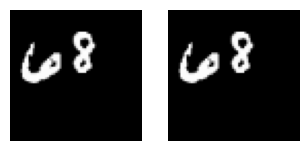

Ground Truth


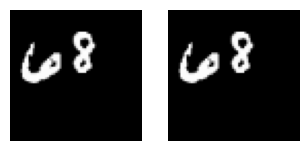

Predicted Sequence


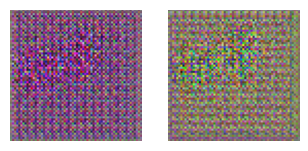

In [34]:
generate_sequences(generator, sample)

## Training

- For each example input generates an output.
- The discriminator receives the `input_image` and the generated image as the first input. The second input is the `input_image` and the `target_image`.
- Next, calculate the generator and the discriminator loss.
- Then, calculate the gradients of loss with respect to both the generator and the discriminator variables(inputs) and apply those to the optimizer.
- Finally, log the losses to TensorBoard.

In [35]:
train_dataset = tf.data.Dataset.from_generator(train_generator, 
    output_signature=(tf.TensorSpec(shape=(None, FRAMES_GROUP_SIZE, IMG_WIDTH, IMG_HEIGHT, N_CHANNELS), dtype=tf.float32),
                      tf.TensorSpec(shape=(None, FRAMES_GROUP_SIZE, IMG_WIDTH, IMG_HEIGHT, N_CHANNELS), dtype=tf.float32)
    )
)

test_dataset = tf.data.Dataset.from_generator(test_generator, 
    output_signature=(tf.TensorSpec(shape=(None, FRAMES_GROUP_SIZE, IMG_WIDTH, IMG_HEIGHT, N_CHANNELS), dtype=tf.float32),
                      tf.TensorSpec(shape=(None, FRAMES_GROUP_SIZE, IMG_WIDTH, IMG_HEIGHT, N_CHANNELS), dtype=tf.float32)
    )
)

In [36]:
log_dir=Path(BASE_DIR) / "logs/"
log_file = log_dir / "fit" / datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

summary_writer = tf.summary.create_file_writer(str(log_file))

In [37]:
@tf.function
def train_step(input_image, target, step):
  with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
    gen_output = generator(input_image, training=True)

    disc_real_output = discriminator([input_image, target], training=True)
    disc_generated_output = discriminator([input_image, gen_output], training=True)
    
    gen_total_loss, gen_gan_loss, gen_l1_loss, gen_custom_loss = generator_loss(disc_generated_output, gen_output, target)
    disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

  generator_gradients = gen_tape.gradient(gen_total_loss,
                                          generator.trainable_variables)
  discriminator_gradients = disc_tape.gradient(disc_loss,
                                               discriminator.trainable_variables)

  generator_optimizer.apply_gradients(zip(generator_gradients,
                                          generator.trainable_variables))
  discriminator_optimizer.apply_gradients(zip(discriminator_gradients,
                                              discriminator.trainable_variables))

  with summary_writer.as_default():
    summary_step = step//1000
    tf.summary.scalar(f'{TESTING_LOSS}_gen_total_loss_l1_{LAMBDA1}_l2_{LAMBDA2}', gen_total_loss, step=summary_step)
    tf.summary.scalar(f'{TESTING_LOSS}_gen_gan_loss_l1_{LAMBDA1}_l2_{LAMBDA2}', gen_gan_loss, step=summary_step)
    tf.summary.scalar(f'{TESTING_LOSS}_gen_l1_loss_l1_{LAMBDA1}_l2_{LAMBDA2}', gen_l1_loss, step=summary_step)
    tf.summary.scalar(f'{TESTING_LOSS}_gen_custom_loss_l1_{LAMBDA1}_l2_{LAMBDA2}', gen_custom_loss, step=summary_step)
    tf.summary.scalar(f'{TESTING_LOSS}_disc_loss_l1_{LAMBDA1}_l2_{LAMBDA2}', disc_loss, step=summary_step)

The actual training loop. Since this tutorial can run of more than one dataset, and the datasets vary greatly in size the training loop is setup to work in steps instead of epochs.

- Iterates over the number of steps.
- Every 10 steps print a dot (`.`).
- Every 1k steps: clear the display and run `generate_sequences` to show the progress.
- Every 5k steps: save a checkpoint.

In [38]:
def fit(train_ds, test_ds, steps):
  iter_test_ds = iter(test_ds.take(1))
  example_input, example_target = next(iter_test_ds)
  
  pbar = tqdm(train_ds.repeat().take(steps).enumerate(), total=steps)
  for step, (input_sequence, target_sequence) in pbar:

    if (step) % 1000 == 0:
      clear_output(wait=True)
      generate_sequences(generator, example_input, example_target)
      print("Working on input:")
      plot_sequence_from_normalized_tensor(input_sequence)
      print("Working on target:")
      plot_sequence_from_normalized_tensor(target_sequence)
      display(pbar.container)
    
    train_step(input_sequence, target_sequence, step)
    
    # Save (checkpoint) the model every 5k steps
    if (step + 1) % 5000 == 0:
        checkpoint.save(file_prefix=checkpoint_prefix)

This training loop saves logs that you can view in TensorBoard to monitor the training progress.

If you work on a local machine, you would launch a separate TensorBoard process. When working in a notebook, launch the viewer before starting the training to monitor with TensorBoard.

To launch the viewer paste the following into a code-cell:

In [39]:
# %load_ext tensorboard
# %tensorboard --logdir {str(log_dir)}

Finally, run the training loop:

Input Sequence


<Figure size 1500x1500 with 0 Axes>

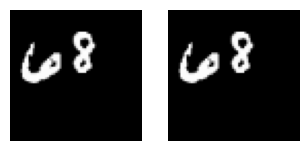

Ground Truth


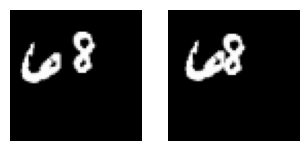

Predicted Sequence


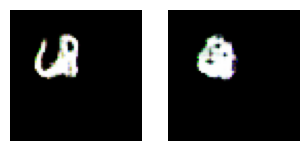

Working on input:


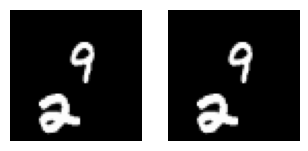

Working on target:


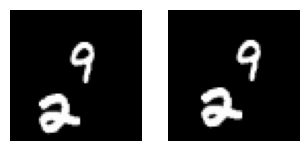

 98%|#########7| 39000/40000 [1:22:50<02:13,  7.51it/s]

In [40]:
fit(train_dataset, test_dataset, steps=40000)

If you want to share the TensorBoard results _publicly_, you can upload the logs to [TensorBoard.dev](https://tensorboard.dev/) by copying the following into a code-cell.

Note: This requires a Google account.

```
!tensorboard dev upload --logdir {log_dir}
```

Caution: This command does not terminate. It's designed to continuously upload the results of long-running experiments. Once your data is uploaded you need to stop it using the "interrupt execution" option in your notebook tool.

You can view the [results of a previous run](https://tensorboard.dev/experiment/lZ0C6FONROaUMfjYkVyJqw) of this notebook on [TensorBoard.dev](https://tensorboard.dev/).

[TensorBoard.dev](https://tensorboard.dev){:.external} is a managed experience for hosting, tracking, and sharing ML experiments with everyone.

It can also included inline using an `<iframe>`:

In [41]:
# display.IFrame(
#     src="https://tensorboard.dev/experiment/lZ0C6FONROaUMfjYkVyJqw",
#     width="100%",
#     height="1000px")

Interpreting the logs is more subtle when training a GAN (or a cGAN like pix2pix) compared to a simple classification or regression model. Things to look for:

- Check that neither the generator nor the discriminator model has "won". If either the `gen_gan_loss` or the `disc_loss` gets very low, it's an indicator that this model is dominating the other, and you are not successfully training the combined model.
- The value `log(2) = 0.69` is a good reference point for these losses, as it indicates a perplexity of 2 - the discriminator is, on average, equally uncertain about the two options.
- For the `disc_loss`, a value below `0.69` means the discriminator is doing better than random on the combined set of real and generated images.
- For the `gen_gan_loss`, a value below `0.69` means the generator is doing better than random at fooling the discriminator.
- As training progresses, the `gen_l1_loss` should go down.

## Restore the latest checkpoint and test the network

In [42]:
!ls {checkpoint_dir}

checkpoint		    ckpt-5.data-00000-of-00001
ckpt-1.data-00000-of-00001  ckpt-5.index
ckpt-1.index		    ckpt-6.data-00000-of-00001
ckpt-2.data-00000-of-00001  ckpt-6.index
ckpt-2.index		    ckpt-7.data-00000-of-00001
ckpt-3.data-00000-of-00001  ckpt-7.index
ckpt-3.index		    ckpt-8.data-00000-of-00001
ckpt-4.data-00000-of-00001  ckpt-8.index
ckpt-4.index


In [43]:
# Restoring the latest checkpoint in checkpoint_dir
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

## Generate some images using the test set

Input Sequence


<Figure size 1500x1500 with 0 Axes>

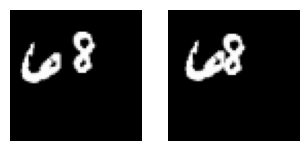

Ground Truth


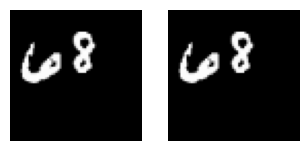

Predicted Sequence


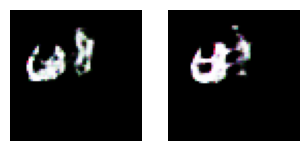

Input Sequence


<Figure size 1500x1500 with 0 Axes>

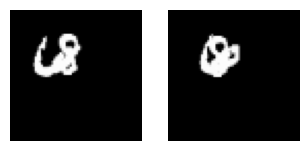

Ground Truth


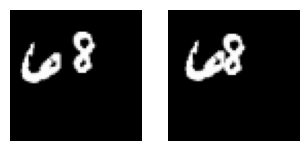

Predicted Sequence


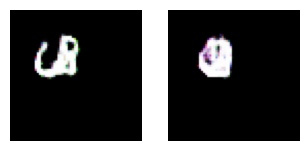

Input Sequence


<Figure size 1500x1500 with 0 Axes>

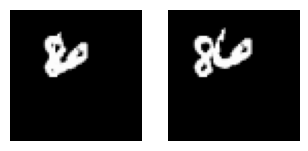

Ground Truth


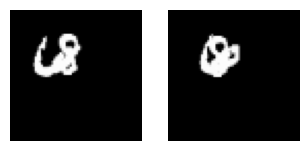

Predicted Sequence


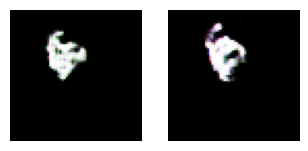

Input Sequence


<Figure size 1500x1500 with 0 Axes>

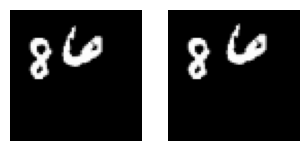

Ground Truth


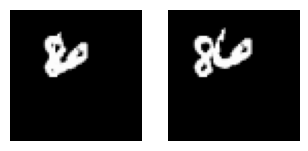

Predicted Sequence


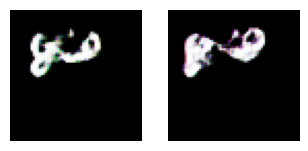

Input Sequence


<Figure size 1500x1500 with 0 Axes>

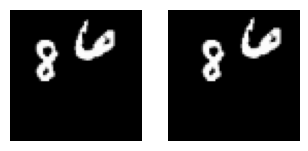

Ground Truth


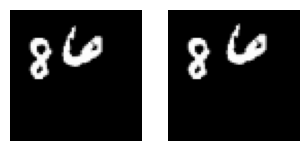

Predicted Sequence


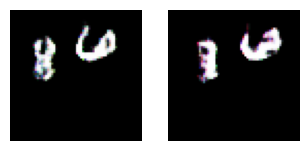

Input Sequence


<Figure size 1500x1500 with 0 Axes>

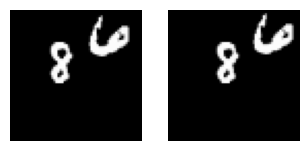

Ground Truth


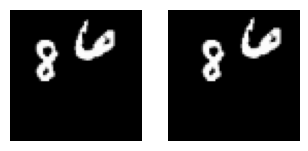

Predicted Sequence


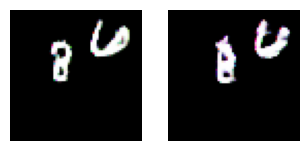

Input Sequence


<Figure size 1500x1500 with 0 Axes>

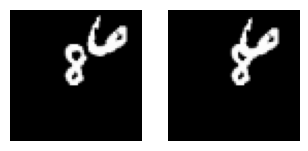

Ground Truth


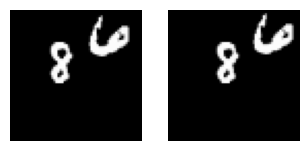

Predicted Sequence


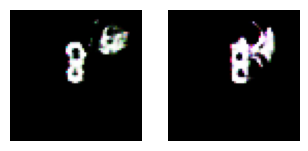

Input Sequence


<Figure size 1500x1500 with 0 Axes>

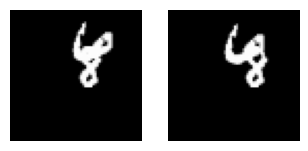

Ground Truth


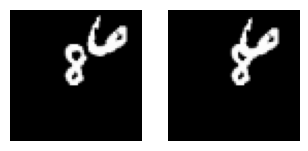

Predicted Sequence


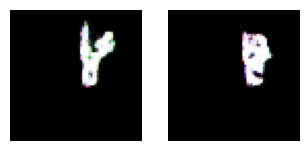

Input Sequence


<Figure size 1500x1500 with 0 Axes>

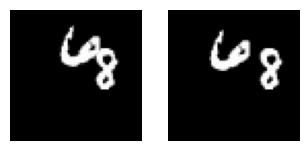

Ground Truth


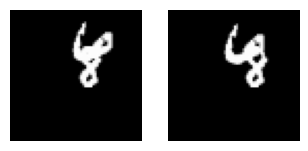

Predicted Sequence


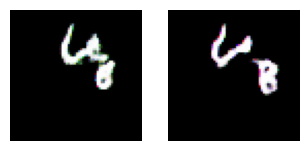

Input Sequence


<Figure size 1500x1500 with 0 Axes>

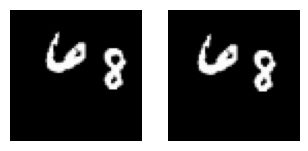

Ground Truth


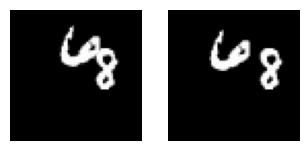

Predicted Sequence


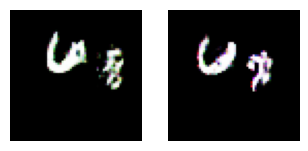

Input Sequence


<Figure size 1500x1500 with 0 Axes>

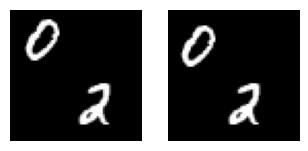

Ground Truth


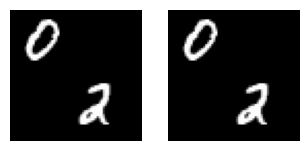

Predicted Sequence


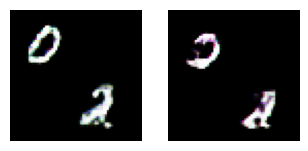

Input Sequence


<Figure size 1500x1500 with 0 Axes>

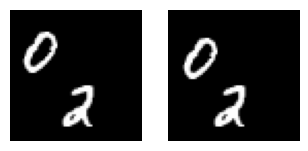

Ground Truth


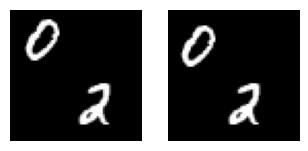

Predicted Sequence


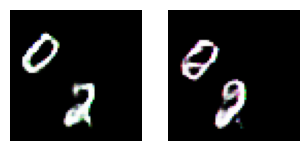

Input Sequence


<Figure size 1500x1500 with 0 Axes>

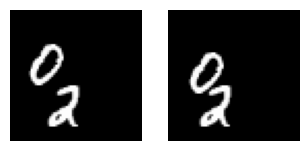

Ground Truth


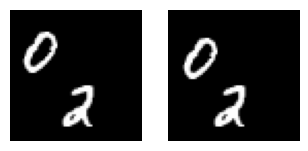

Predicted Sequence


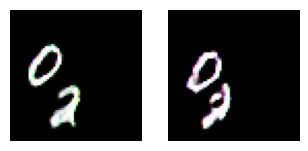

Input Sequence


<Figure size 1500x1500 with 0 Axes>

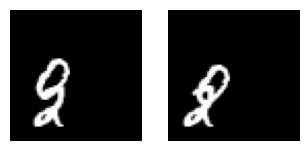

Ground Truth


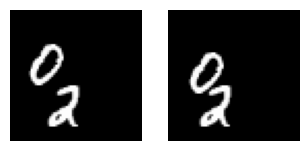

Predicted Sequence


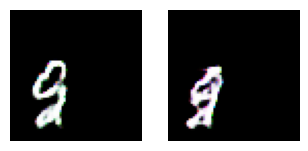

Input Sequence


<Figure size 1500x1500 with 0 Axes>

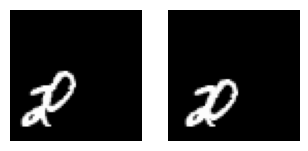

Ground Truth


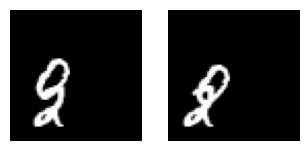

Predicted Sequence


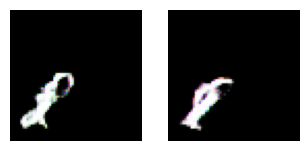

Input Sequence


<Figure size 1500x1500 with 0 Axes>

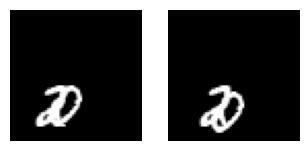

Ground Truth


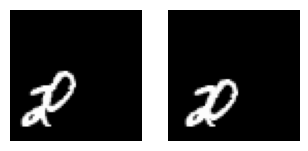

Predicted Sequence


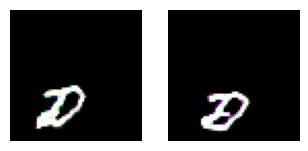

Input Sequence


<Figure size 1500x1500 with 0 Axes>

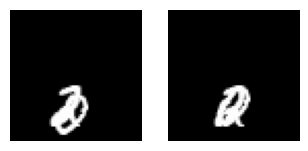

Ground Truth


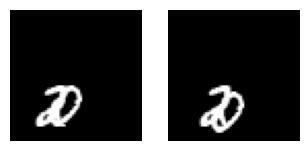

Predicted Sequence


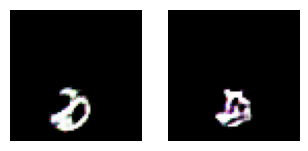

Input Sequence


<Figure size 1500x1500 with 0 Axes>

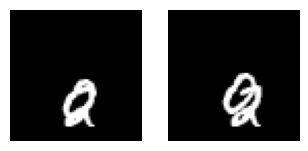

Ground Truth


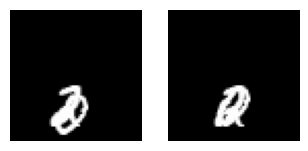

Predicted Sequence


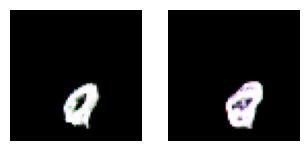

Input Sequence


<Figure size 1500x1500 with 0 Axes>

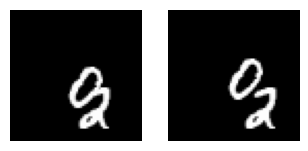

Ground Truth


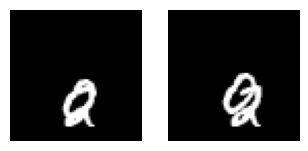

Predicted Sequence


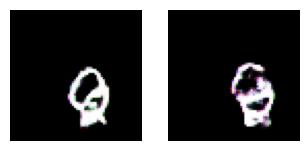

Input Sequence


<Figure size 1500x1500 with 0 Axes>

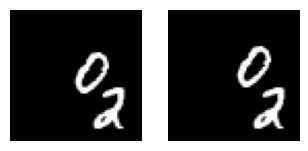

Ground Truth


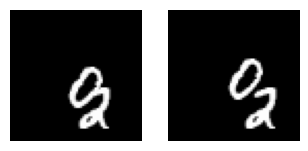

Predicted Sequence


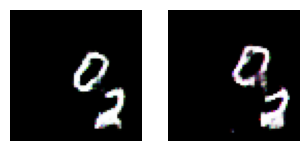

In [44]:
for i in range(0,20):
  input_sequence, target_sequence, generated_output = test_generator.predict(i, generator, False)
  plot_results(input_sequence, target_sequence, generated_output)

In [45]:
# evaluating the results with SSIM
def evaluate_metrics(target_sequence, generated_output):
    #compute ssim
    ssim_score = tf.image.ssim(generated_output, target_sequence, max_val=255)
    #compute psnr
    psnr_score = tf.image.psnr(generated_output, target_sequence, max_val=255)
    #compute mse
    mse_score = tf.keras.losses.MSE(generated_output, target_sequence)
    #compute l1
    l1_score = tf.keras.losses.MAE(generated_output, target_sequence)
    return ssim_score, psnr_score, mse_score, l1_score

ssim_scores = []
psnr_scores = []
mse_scores = []
l1_scores = []

for i in tqdm(range(len(test_generator))):
    input_sequence, target_sequence, generated_output = test_generator.predict(i, generator, False)
    ssim_score, psnr_score, mse_score, l1_score = evaluate_metrics(target_sequence, generated_output)
    ssim_scores.append(ssim_score)
    psnr_scores.append(psnr_score)
    mse_scores.append(mse_score)
    l1_scores.append(l1_score)

print(f"SSIM score: {tf.math.reduce_mean(ssim_scores)}")
print(f"PSNR score: {tf.math.reduce_mean(psnr_scores)}")
print(f"MSE score: {tf.math.reduce_mean(mse_scores)}")
print(f"L1 score: {tf.math.reduce_mean(l1_scores)}")

  0%|          | 0/3000 [00:00<?, ?it/s]

SSIM score: 0.9935489296913147
PSNR score: 58.58442687988281
MSE score: 0.10217026621103287
L1 score: 0.07297055423259735


## Different order

In [ ]:
new_order = [0, 10, 1, 11, 2, 12, 3, 13, 4, 14, 5, 15, 6, 16, 7, 17, 8, 18, 9]

# # Run the trained model on a few examples from the test set
# for i, (inp, tar) in enumerate(test_dataset.take(5)):
#   inp = tf.gather(inp, new_order, axis=-1)
#   tar = tf.gather(tar, new_order, axis=-1)
#   # inp = inp[..., new_order]
#   # tar = tar[..., new_order]
#   print(i)
#   generate_sequences(generator, inp, tar, save_dir=save_dir)